# Toy integral

This mini notebook explains:

1. The oscillatory integral
   $$I = \int_{-\infty}^{\infty} e^{i x^2}\,dx$$
2. Why arrows cancel on the real line
3. How contour rotation (thimble intuition) fixes it
4. A tiny ML setup that learns the contour angle
5. How to verify the learned contour is correct

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42) 
torch.manual_seed(42)
%matplotlib inline

## 1) Exact answer and thimble picture

$$
I = \int_{-\infty}^{\infty} e^{i x^2}\,dx
$$

### Why is this integral is a little tricky? The arrow picture

On the **real axis**, at each $x$ the integrand $e^{ix^2}$ is a complex number. Think of it as an **arrow** in the complex plane:
- **Length:** $|e^{ix^2}| = 1$ for all $x$ — every arrow lies on the unit circle.
- **Direction (phase):** $\arg(e^{ix^2}) = x^2$ radians — the angle is $x^2$.

As $x$ runs from $-\infty$ to $+\infty$, $x^2$ runs from $\infty \to 0 \to \infty$, so the phase spins around the circle. The arrows point in all directions. When we integrate (sum these arrows), they **cancel** — that's why the integral is hard to evaluate on the real line.

| $x$ | $x^2$ | $e^{ix^2}$ | Arrow |
|-----|-------|------------|-------|
| 0 | 0 | 1 | → (right) |
| 1 | 1 | $e^i \approx 0.54+0.84i$ | ↗ (~58°) |
| $\sqrt{\pi}$ | $\pi$ | $-1$ | ← (180°) |
| 2 | 4 | $e^{4i}$ | ↙ (~250°) |

The diagrams below show: (left) arrows on the real axis — scattered around the circle, cancelling; (right) arrows on the thimble at $\theta=\pi/4$ — aligned, so they add constructively.

### How do we fix it? Rotate the contour

Substitute $x = e^{i\pi/4} z$

so $dx = e^{i\pi/4}\,dz$.

Then

$$
I = \int_{-\infty}^{\infty} e^{i (e^{i\pi/4}z)^2} \, e^{i\pi/4} dz  \,\,\,\,\,\,  (1) 
$$

Since

$$
(e^{i\pi/4})^2 = e^{i\pi/2} = i
$$

(as $cos(\pi/2)+isin(\pi/2) = 0 + i = i$)

we have

$$
i(e^{i\pi/4}z)^2 = i \cdot i z^2 = -z^2.
$$

Therefore

$$
I = e^{i\pi/4} \int_{-\infty}^{\infty} e^{-z^2} dz
$$

Using

$$
\int_{-\infty}^{\infty} e^{-z^2} dz = \sqrt{\pi}
$$

we obtain

$$
I = e^{i\pi/4}\sqrt{\pi}.
$$

**Thimble picture:** At $\theta=\pi/4$, the integrand becomes $e^{-z^2}$ (non-oscillatory)—the steepest-descent direction. **The thimble rotates us from phase-cancelling arrows to aligned arrows**.

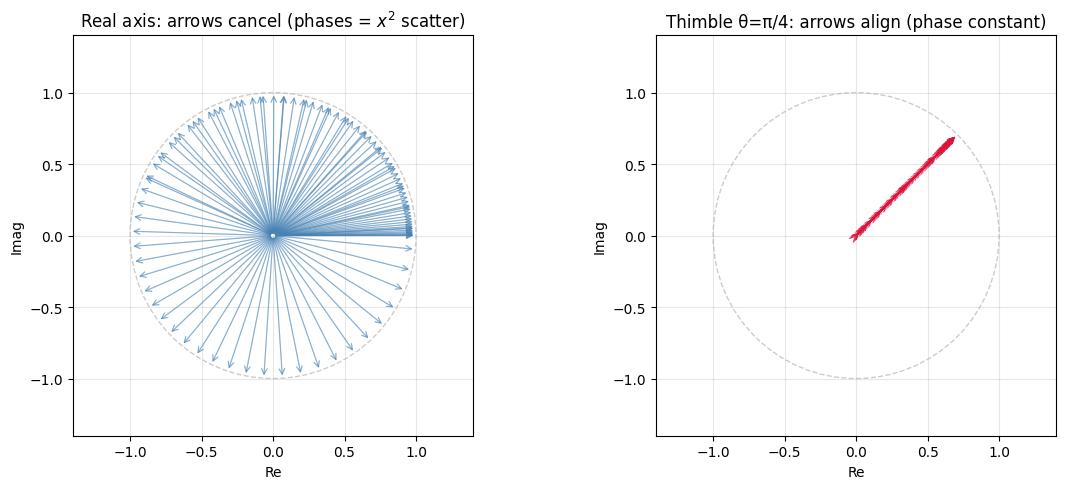

In [3]:
# Arrow diagrams: real axis (cancelling) vs thimble at θ=π/4 (aligned)
n_arrows = 200

# Left: real axis — integrand e^{ix²} at sample points x
x_vals = np.linspace(-3, 3, n_arrows)
W_real = np.exp(1j * x_vals**2)  # all on unit circle, phases = x²

# Right: thimble at θ=π/4 — W = e^{iπ/4}·e^{-z²}, z ~ N(0,1)
np.random.seed(42)
z_vals = np.random.randn(n_arrows)
W_thimble = np.exp(1j * np.pi/4) * np.exp(-z_vals**2)  # aligned phase π/4
W_thimble = W_thimble / np.max(np.abs(W_thimble))  # scale for visibility

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(n_arrows):
    axes[0].annotate('', xy=(W_real[i].real, W_real[i].imag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.4, lw=0.8))
    axes[1].annotate('', xy=(W_thimble[i].real, W_thimble[i].imag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.4, lw=0.8))

axes[0].add_patch(plt.Circle((0, 0), 1, fill=False, ls='--', color='gray', alpha=0.4))
axes[0].set_title('Real axis: arrows cancel (phases = $x^2$ scatter)')
axes[0].set_xlim(-1.4, 1.4); axes[0].set_ylim(-1.4, 1.4)
axes[0].set_aspect('equal'); axes[0].set_xlabel('Re'); axes[0].set_ylabel('Imag')
axes[0].grid(True, alpha=0.3)

axes[1].add_patch(plt.Circle((0, 0), 1, fill=False, ls='--', color='gray', alpha=0.4))
axes[1].set_title('Thimble θ=π/4: arrows align (phase constant)')
axes[1].set_xlim(-1.4, 1.4); axes[1].set_ylim(-1.4, 1.4)
axes[1].set_aspect('equal'); axes[1].set_xlabel('Re'); axes[1].set_ylabel('Imag')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [4]:
I_exact = np.sqrt(np.pi) * np.exp(1j * np.pi / 4)
print(f"Exact I = {I_exact:.10f}")
print(f"|I_exact| = {abs(I_exact):.10f}")
print(f"phase(I_exact) = {np.angle(I_exact):.6f} rad")

Exact I = 1.2533141373+1.2533141373j
|I_exact| = 1.7724538509
phase(I_exact) = 0.785398 rad


## 2) Tiny ML model: learn the contour angle

For this 1D toy problem, the "network" can be just one parameter: $\theta$.

### The weight $W$

**The weight $W$ is the contribution of one sampled path (or one sampled point) to the integral after the contour has been deformed into the complex plane.**

We deform the contour by substituting $x = e^{i\theta} z$ with $z \sim \mathcal{N}(0,1)$. The integrand becomes $e^{i x^2} = e^{i (e^{i\theta} z)^2}$, and the Jacobian is $dx/dz = e^{i\theta}$. So at each sampled $z$, the weight is
$$W = e^{i\theta} \cdot e^{i e^{2i\theta} z^2}.$$
This is from (1) above.
The Monte Carlo estimate is $\langle W \rangle$ over samples. Each $W$ is that sample's contribution to the integral.

So NOTE ... in this Toy example we dont need Monte Carlo - but in more complicated cases (e.g. lattice field theory, many-dimensional path integrals) we will!

When there is no closed-form answer Monte Carlo sampling is often the only practical way to estimate the integal

### The loss function

We minimize the **phase variance** of the log-weights:
$$\mathcal L = \mathrm{Var}(\mathrm{Im}\log W) .$$

- **$\mathrm{Var}(\mathrm{Im}\log W)$**: Minimizing this aligns the *phases* (angles) of the weights—the hallmark of the steepest-descent thimble, where arrows point in the same direction instead of cancelling.




**Note: For the QHO and more complex problems we will also need  $\mathrm{Var}(\Re\log W)$** in the loss function for scaling.

- **$\mathrm{Var}(\Re\log W)$** (log-magnitude variance): In general, minimizing this stabilizes the *magnitudes* of the weights (since $\Re\log W = \log|W|$), reducing variance in the Monte Carlo estimate. For this toy problem it is redundant, but it matters in higher dimensions.

**If training works, $\theta$ should move near $\pi/4$**.

[Maths Note (ignore if u already know)  on Why $\mathrm{Im}(\log W)$ is the angle (trig form)

Write $W$ in polar form with trig:
$$W = |W|(\cos\phi + i\sin\phi),$$
where $\phi$ is the angle of $W$ in the complex plane.

$$\log W = \log|W| + \log(\cos\phi + i\sin\phi).$$
For a point on the unit circle, $\cos\phi + i\sin\phi$, the complex logarithm is
$$\log(\cos\phi + i\sin\phi) = i\phi.$$
So
$$\log W = \log|W| + i\phi.$$
The real part is $\log|W|$ and the imaginary part is $\phi$:
$$\mathrm{Im}(\log W) = \phi = \arg(W).$$
So $\mathrm{Im}(\log W)$ is exactly the angle of $W$.]



In [5]:
# Weight W = e^{iθ} · e^{i e^{2iθ} z²} and its log (branch-safe: closed form, no log branch cut)
def weights_from_theta(theta, z):
    return torch.exp(1j * theta) * torch.exp(1j * torch.exp(2j * theta) * z**2)

def log_weight_branch_safe(theta, z):
    return 1j * theta + 1j * torch.exp(2j * theta) * z**2

In [6]:
# Start from the naive real-axis contour (theta~0) and let the optimizer find the thimble
theta_param = torch.nn.Parameter(torch.tensor(0.1))
opt = torch.optim.Adam([theta_param], lr=0.01)

epochs = 600
batch_size = 16384

loss_hist = []
theta_hist = []
I_est_hist = []

for ep in range(epochs):
    opt.zero_grad()
    z = torch.randn(batch_size)
    logW = log_weight_branch_safe(theta_param, z)
    # Phase variance only: Var(Re) + Var(Im) = const, so the sum has no gradient.
    # The thimble aligns phases, so we minimise phase variance = Var(Im log W).
    
    ############## The loss Function ###################
    loss = torch.var(logW.imag)
    ############## The loss Function ################### 
    loss.backward()
    opt.step()

    with torch.no_grad():
        theta_hist.append(theta_param.item())
        loss_hist.append(loss.item())
        W_now = weights_from_theta(theta_param, z)
        I_est_hist.append(torch.mean(W_now).item())

    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"Epoch {ep+1:4d} | loss={loss.item():.4e} | theta={theta_param.item():.6f}")

theta_learned = theta_param.item()
print('\nLearned theta:', theta_learned)
print('Target theta  :', np.pi/4)

c:\Users\tomqu\Documents\MLandPython\envs\helios_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch    1 | loss=1.9034e+00 | theta=0.110000
Epoch  100 | loss=1.0662e-03 | theta=0.796512
Epoch  200 | loss=3.3823e-10 | theta=0.785399
Epoch  300 | loss=1.0314e-13 | theta=0.785398
Epoch  400 | loss=1.0029e-13 | theta=0.785398
Epoch  500 | loss=8.1776e-14 | theta=0.785398
Epoch  600 | loss=7.8249e-14 | theta=0.785398

Learned theta: 0.7853982448577881
Target theta  : 0.7853981633974483


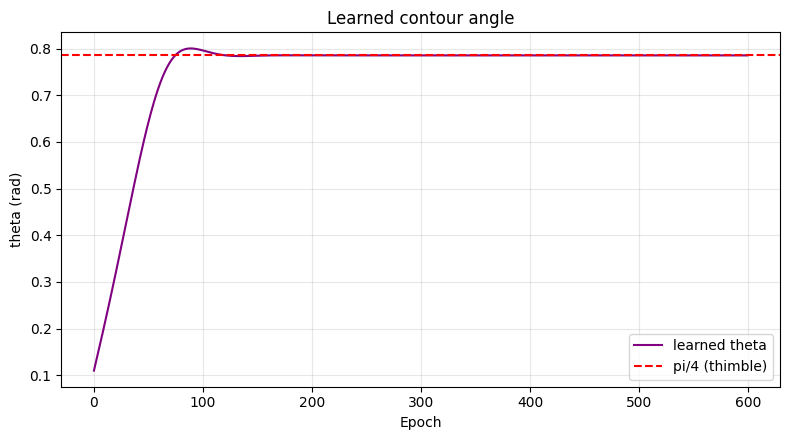

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(theta_hist, color='purple', label='learned theta')
ax.axhline(np.pi/4, color='red', ls='--', label='pi/4 (thimble)')
ax.set_title('Learned contour angle')
ax.set_xlabel('Epoch')
ax.set_ylabel('theta (rad)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 4) Verify correctness

We verify in 3 ways:

1. **Geometry check**: learned $\theta \approx \pi/4$.
2. **Arrow alignment check**: direction concentration improves.
3. **Physics check**: Monte Carlo estimate matches exact Fresnel value.

In [8]:
def alignment_score(W):
    ang = np.angle(W)
    return np.abs(np.mean(np.exp(1j * ang)))

with torch.no_grad():
    z_eval = torch.randn(100000)
    W_before = weights_from_theta(torch.tensor(0.0), z_eval)
    W_after = weights_from_theta(torch.tensor(theta_learned), z_eval)

I_before = torch.mean(W_before).item()
I_after = torch.mean(W_after).item()

R_before = alignment_score(W_before.numpy())
R_after = alignment_score(W_after.numpy())

err_after = abs(I_after - I_exact) / abs(I_exact)

print(f"Learned theta            = {theta_learned:.6f} rad")
print(f"Target theta (pi/4)      = {np.pi/4:.6f} rad")
print()
print(f"Alignment score before   = {R_before:.4f}")
print(f"Alignment score after    = {R_after:.4f}")
print()
print(f"I_exact                  = {I_exact:.10f}")
print(f"I_est (theta=0)          = {I_before:.10f}")
print(f"I_est (learned theta)    = {I_after:.10f}")
print(f"Relative error (learned) = {err_after:.2e}")

Learned theta            = 0.785398 rad
Target theta (pi/4)      = 0.785398 rad

Alignment score before   = 0.6687
Alignment score after    = 1.0000

I_exact                  = 1.2533141373+1.2533141373j
I_est (theta=0)          = 0.5687873960+0.3516204655j
I_est (learned theta)    = 0.4091988206+0.4091988206j
Relative error (learned) = 6.74e-01


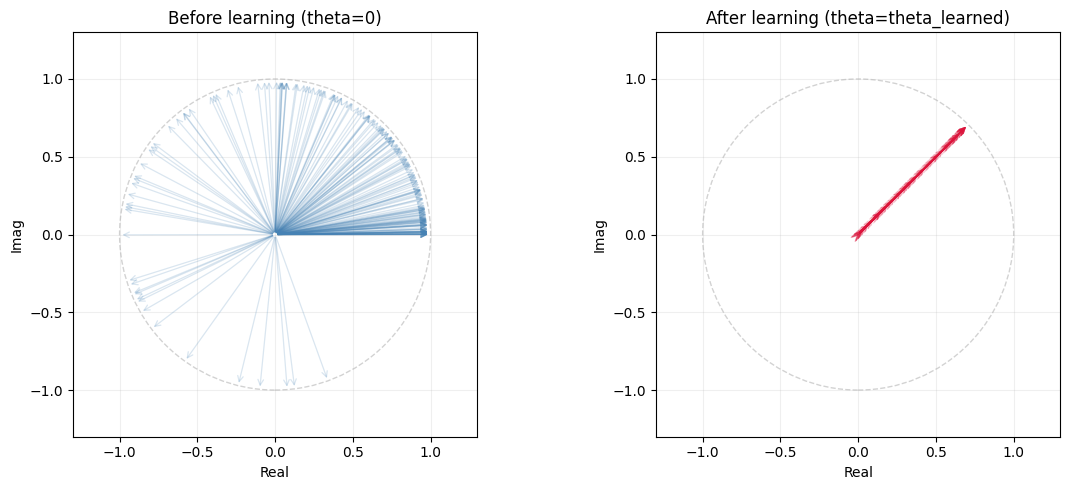

In [9]:
# Arrow plot before vs learned (same samples)
n_arrow_cmp = 200
with torch.no_grad():
    z_cmp = torch.randn(n_arrow_cmp)
    W_b = weights_from_theta(torch.tensor(0.0), z_cmp)
    W_a = weights_from_theta(torch.tensor(theta_learned), z_cmp)
    W_b = (W_b / torch.max(torch.abs(W_b))).numpy()
    W_a = (W_a / torch.max(torch.abs(W_a))).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i in range(n_arrow_cmp):
    axes[0].annotate('', xy=(W_b[i].real, W_b[i].imag), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='steelblue', alpha=0.2, lw=0.9))
    axes[1].annotate('', xy=(W_a[i].real, W_a[i].imag), xytext=(0,0),
                     arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.2, lw=0.9))

axes[0].set_title('Before learning (theta=0)')
axes[1].set_title('After learning (theta=theta_learned)')
for ax in axes:
    ax.add_patch(plt.Circle((0,0), 1, fill=False, ls='--', color='gray', alpha=0.35))
    ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_aspect('equal')
    ax.set_xlabel('Real'); ax.set_ylabel('Imag')
    ax.grid(True, alpha=0.2)

plt.tight_layout(); plt.show()

### What the substitution/thimble has done visually

The plot below shows the **original path** (real axis, horizontal) and the **learned thimble** (rotated by $\theta=\pi/4$). At $\theta=\pi/4$, $x = e^{i\pi/4} z$ maps the real $z$ axis into a line at 45° in the complex plane—where the oscillatory integrand becomes a real Gaussian.

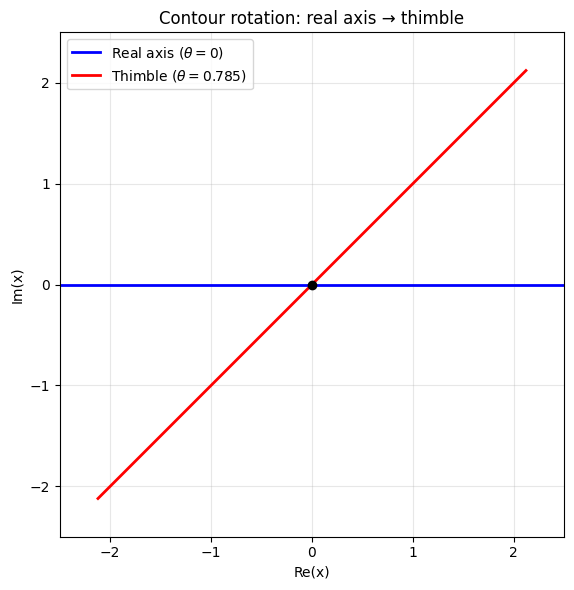

In [10]:
# Contour: real axis vs rotated thimble
th = theta_learned
z_line = np.linspace(-3, 3, 200)
x_real = z_line + 0j  # real axis
x_thimble = np.exp(1j * th) * z_line  # rotated contour

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_real.real, x_real.imag, 'b-', lw=2, label='Real axis ($\\theta=0$)')
ax.plot(x_thimble.real, x_thimble.imag, 'r-', lw=2, label=f'Thimble ($\\theta={th:.3f}$)')
ax.plot(0, 0, 'ko', ms=6)
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_xlabel('Re(x)'); ax.set_ylabel('Im(x)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Contour rotation: real axis → thimble')
plt.tight_layout(); plt.show()

## 5) Computing the actual integral via Monte Carlo

We want to evaluate
$$I = \int_{-\infty}^{\infty} e^{ix^2}\,dx.$$

After the contour rotation $x = e^{i\theta}z$, the integral becomes
$$I = \int_{-\infty}^{\infty} W(z)\,dz, \qquad W(z) = e^{i\theta}\,e^{i\,e^{2i\theta}\,z^2}.$$

We sample $z \sim \mathcal{N}(0,1)$ with pdf $\;p(z) = \frac{1}{\sqrt{2\pi}}\,e^{-z^2/2}$, so by importance sampling:
$$I = \int_{-\infty}^{\infty} \frac{W(z)}{p(z)}\,p(z)\,dz = \mathbb{E}_{z\sim p}\!\left[\frac{W(z)}{p(z)}\right] \approx \frac{1}{N}\sum_{i=1}^{N} \frac{W(z_i)}{p(z_i)}.$$

Since $\;p(z) = \frac{1}{\sqrt{2\pi}}\,e^{-z^2/2}\;$, the correction factor is $\;\frac{1}{p(z)} = \sqrt{2\pi}\,e^{z^2/2}\;$, giving the estimator

$$\hat I = \frac{1}{N}\sum_{i=1}^{N} W(z_i)\,\sqrt{2\pi}\,e^{z_i^2/2}.$$

**Note:** the `torch.mean(W)` used in Section 4 does **not** include this $1/p(z)$ correction, which is why its "I_est" has a large relative error. Below we compute the integral properly.

In [11]:
N_mc = 1_000_000

with torch.no_grad():
    z_mc = torch.randn(N_mc)

    # Importance weight correction: 1/p(z) = sqrt(2π) * exp(z²/2)
    inv_p = np.sqrt(2 * np.pi) * torch.exp(z_mc**2 / 2)

    # --- Before learning (real axis, theta=0) ---
    W_mc_before = weights_from_theta(torch.tensor(0.0), z_mc)
    I_mc_before = torch.mean(W_mc_before * inv_p).item()

    # --- After learning (thimble, theta ≈ π/4) ---
    W_mc_after = weights_from_theta(torch.tensor(theta_learned), z_mc)
    I_mc_after = torch.mean(W_mc_after * inv_p).item()

err_before = abs(I_mc_before - I_exact) / abs(I_exact)
err_after  = abs(I_mc_after  - I_exact) / abs(I_exact)

print("=== Monte Carlo estimate of I = ∫ e^{ix²} dx ===")
print(f"  N samples              = {N_mc:,}")
print()
print(f"  I_exact                = {I_exact:.10f}")
print()
print(f"  I_MC  (theta=0)        = {I_mc_before:.10f}")
print(f"  Rel. error (theta=0)   = {err_before:.2e}")
print()
print(f"  I_MC  (learned theta)  = {I_mc_after:.10f}")
print(f"  Rel. error (learned)   = {err_after:.2e}")
print()
print("The thimble (learned theta ≈ π/4) dramatically reduces the MC error")
print("because the integrand is no longer oscillatory — arrows align.")

=== Monte Carlo estimate of I = ∫ e^{ix²} dx ===
  N samples              = 1,000,000

  I_exact                = 1.2533141373+1.2533141373j

  I_MC  (theta=0)        = 1.1646574736+1.0634925365j
  Rel. error (theta=0)   = 1.18e-01

  I_MC  (learned theta)  = 1.2535384893+1.2535384893j
  Rel. error (learned)   = 1.79e-04

The thimble (learned theta ≈ π/4) dramatically reduces the MC error
because the integrand is no longer oscillatory — arrows align.
